In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import math
import time
from sklearn.metrics import accuracy_score, f1_score
from collections import Counter


torch.manual_seed(42)


if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


## 1. Configuration

In [2]:
DATASET_NAME = "ag_news"
NUM_CLASSES = 4
MAX_SEQ_LEN = 128

BATCH_SIZE = 32
EPOCHS_SCRATCH = 15
EPOCHS_FINETUNE = 5
PATIENCE = 3

FS_EMBED_SIZE = 64
FS_NHEAD = 4
FS_HIDDEN_SIZE = 256
FS_NUM_LAYERS = 4
FS_DROPOUT = 0.1
FS_LR = 1e-3

PRETRAINED_MODEL_NAME = "roneneldan/TinyStories-33M"
FT_LR = 5e-5

## 2. Data Loading & Preprocessing

In [3]:
print(f"Loading {DATASET_NAME} dataset...")
dataset = load_dataset(DATASET_NAME)


split_data = dataset["train"].train_test_split(test_size=0.1, seed=42)
train_dataset = split_data["train"]
val_dataset = split_data["test"]
test_dataset = dataset["test"]

print(
    f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}"
)

print("\n--- Data Inspection ---")
print("Sample examples:")
for i in range(2):
    print(f"Text: {train_dataset[i]['text'][:100]}...")
    print(f"Label: {train_dataset[i]['label']}")


def print_distribution(ds, name):
    labels = [x["label"] for x in ds]
    counts = Counter(labels)
    print(f"\n{name} Distribution: {dict(sorted(counts.items()))}")


print_distribution(train_dataset, "Train")
print_distribution(val_dataset, "Validation")
print("-----------------------")

print(f"\nLoading tokenizer for {PRETRAINED_MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id


def collate_fn(batch):
    texts = [item["text"] for item in batch]
    labels = [item["label"] for item in batch]

    encoding = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_SEQ_LEN,
        return_tensors="pt",
    )

    return {
        "input_ids": encoding["input_ids"],
        "attention_mask": encoding["attention_mask"],
        "labels": torch.tensor(labels, dtype=torch.long),
    }


train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

Loading ag_news dataset...
Train: 108000, Val: 12000, Test: 7600

--- Data Inspection ---
Sample examples:
Text: Despair and Anger in Small Russian Town After Siege  BESLAN, Russia (Reuters) - The killing of more ...
Label: 0
Text: Bob Evans, mainframe pioneer, dies at 77 Evans led a team that developed a new class of mainframe co...
Label: 3

Train Distribution: {0: 26991, 1: 26966, 2: 27100, 3: 26943}

Validation Distribution: {0: 3009, 1: 3034, 2: 2900, 3: 3057}
-----------------------

Loading tokenizer for roneneldan/TinyStories-33M...


## 3. Model Definitions
### 3.1 From-Scratch Model (True Decoder-Only)

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)


class TransformerClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_size: int,
        nhead: int,
        hidden_size: int,
        num_layers: int,
        num_classes: int,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.model_type = "Transformer"
        self.embed_size = embed_size
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.pos_encoder = PositionalEncoding(embed_size, dropout)

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=embed_size,
            nhead=nhead,
            dim_feedforward=hidden_size,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layers, num_layers, enable_nested_tensor=False
        )

        self.classifier = nn.Sequential(
            nn.Linear(embed_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )

        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.classifier[0].bias.data.zero_()
        self.classifier[0].weight.data.uniform_(-initrange, initrange)
        self.classifier[3].bias.data.zero_()
        self.classifier[3].weight.data.uniform_(-initrange, initrange)

    def _generate_square_subsequent_mask(
        self, sz: int, device: torch.device
    ) -> torch.Tensor:
        mask = (torch.triu(torch.ones(sz, sz, device=device)) == 1).transpose(0, 1)
        mask = (
            mask.float()
            .masked_fill(mask == 0, float("-inf"))
            .masked_fill(mask == 1, float(0.0))
        )
        return mask

    def forward(self, src: torch.Tensor, src_mask: torch.Tensor = None) -> torch.Tensor:
        is_pad = src == tokenizer.pad_token_id
        src_key_padding_mask = torch.zeros_like(is_pad, dtype=torch.float)
        src_key_padding_mask.masked_fill_(is_pad, float("-inf"))

        device = src.device
        causal_mask = self._generate_square_subsequent_mask(src.size(1), device)

        src_embed = self.embedding(src) * math.sqrt(self.embed_size)
        src_pos = self.pos_encoder(src_embed)

        output = self.transformer_encoder(
            src_pos, mask=causal_mask, src_key_padding_mask=src_key_padding_mask
        )

        pooled_output = output.mean(dim=1)

        logits = self.classifier(pooled_output)
        return logits


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 4. Training & Evaluation Functions

In [5]:
def train_epoch(
    model, dataloader, optimizer, scheduler, criterion, device, is_huggingface=False
):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    start_time = time.time()

    for batch in tqdm(dataloader, desc="Training", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        if is_huggingface:
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
        else:
            logits = model(input_ids)
            loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()

        if device.type == "mps":
            torch.mps.empty_cache()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    epoch_time = time.time() - start_time
    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, acc, f1, epoch_time


def evaluate(model, dataloader, criterion, device, is_huggingface=False):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            if is_huggingface:
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                logits = outputs.logits
            else:
                logits = model(input_ids)
                loss = criterion(logits, labels)

            if device.type == "mps":
                torch.mps.empty_cache()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, acc, f1


def run_experiment(model_name, model, epochs, lr, patience, is_huggingface=False):
    print(f"\n{'=' * 20} Starting Experiment: {model_name} {'=' * 20}")
    print(f"Parameters: {count_parameters(model):,}")

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()

    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": [],
        "epoch_times": [],
    }

    best_val_loss = float("inf")
    patience_counter = 0

    safe_name = model_name.replace(" ", "_").replace("/", "_").lower()
    best_model_path = f"best_model_{safe_name}.pt"

    total_start = time.time()

    for epoch in range(epochs):
        t_loss, t_acc, t_f1, t_time = train_epoch(
            model, train_loader, optimizer, scheduler, criterion, device, is_huggingface
        )
        v_loss, v_acc, v_f1 = evaluate(
            model, val_loader, criterion, device, is_huggingface
        )

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)
        history["train_f1"].append(t_f1)
        history["val_f1"].append(v_f1)
        history["epoch_times"].append(t_time)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {t_loss:.4f} | "
            f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f} | "
            f"Time: {t_time:.1f}s"
        )

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            patience_counter = 0
            print(f"  -> Validation improved. Saving model to {best_model_path}...")

            torch.save(model.state_dict(), best_model_path)
        else:
            patience_counter += 1
            print(f"  -> No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch + 1} epochs.")
            break

    total_time = time.time() - total_start
    print(f"Total Training Time: {total_time:.1f}s")

    print(f"Loading best model from {best_model_path} for testing...")
    model.load_state_dict(torch.load(best_model_path))

    print("Measuring Inference Speed on Test Set...")
    inf_start = time.time()
    test_loss, test_acc, test_f1 = evaluate(
        model, test_loader, criterion, device, is_huggingface
    )
    inf_time = time.time() - inf_start

    results = {
        "history": history,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "total_train_time": total_time,
        "inference_time": inf_time,
        "params": count_parameters(model),
    }

    return results

## 5. Running Experiments

In [6]:
scratch_model = TransformerClassifier(
    vocab_size=tokenizer.vocab_size,
    embed_size=FS_EMBED_SIZE,
    nhead=FS_NHEAD,
    hidden_size=FS_HIDDEN_SIZE,
    num_layers=FS_NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=FS_DROPOUT,
).to(device)


scratch_results = run_experiment(
    "From-Scratch (Small Decoder)",
    scratch_model,
    epochs=EPOCHS_SCRATCH,
    lr=FS_LR,
    patience=PATIENCE,
    is_huggingface=False,
)


==================== Starting Experiment: From-Scratch (Small Decoder) ====================
Parameters: 3,434,052


Training:   0%|          | 0/3375 [00:00<?, ?it/s]

Epoch 1/15 | Train Loss: 0.5608 | Val Loss: 0.2709 Acc: 0.9071 | Time: 163.3s
  -> Validation improved. Saving model to best_model_from-scratch_(small_decoder).pt...


Training:   0%|          | 0/3375 [00:00<?, ?it/s]

Epoch 2/15 | Train Loss: 0.2288 | Val Loss: 0.2590 Acc: 0.9137 | Time: 151.8s
  -> Validation improved. Saving model to best_model_from-scratch_(small_decoder).pt...


...

Epoch 3/15 | Train Loss: 0.1477 | Val Loss: 0.2685 Acc: 0.9158 | Time: 90.0s
  -> No improvement. Patience: 1/3


Training:   0%|          | 0/3375 [00:00<?, ?it/s]

Epoch 4/15 | Train Loss: 0.0961 | Val Loss: 0.3223 Acc: 0.9184 | Time: 94.8s
  -> No improvement. Patience: 2/3


Training:   0%|          | 0/3375 [00:00<?, ?it/s]

Epoch 5/15 | Train Loss: 0.0611 | Val Loss: 0.4480 Acc: 0.9075 | Time: 179.0s
  -> No improvement. Patience: 3/3

Early stopping triggered after 5 epochs.
Total Training Time: 697.7s
Loading best model from best_model_from-scratch_(small_decoder).pt for testing...
Measuring Inference Speed on Test Set...


In [7]:
print(f"Loading Pretrained {PRETRAINED_MODEL_NAME}...")
ft_model = AutoModelForSequenceClassification.from_pretrained(
    PRETRAINED_MODEL_NAME, num_labels=NUM_CLASSES
)
ft_model.config.pad_token_id = tokenizer.pad_token_id
ft_model.to(device)

ft_results = run_experiment(
    f"Fine-Tuned ({PRETRAINED_MODEL_NAME})",
    ft_model,
    epochs=EPOCHS_FINETUNE,
    lr=FT_LR,
    patience=PATIENCE,
    is_huggingface=True,
)

Loading Pretrained roneneldan/TinyStories-33M...


Some weights of GPTNeoForSequenceClassification were not initialized from the model checkpoint at roneneldan/TinyStories-33M and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



==================== Starting Experiment: Fine-Tuned (roneneldan/TinyStories-33M) ====================
Parameters: 68,517,120


Training:   0%|          | 0/3375 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 0.4503 | Val Loss: 0.2489 Acc: 0.9117 | Time: 1050.9s
  -> Validation improved. Saving model to best_model_fine-tuned_(roneneldan_tinystories-33m).pt...


...

Epoch 3/5 | Train Loss: 0.0927 | Val Loss: 0.3054 Acc: 0.9203 | Time: 1049.1s
  -> No improvement. Patience: 1/3


Training:   0%|          | 0/3375 [00:00<?, ?it/s]

Epoch 4/5 | Train Loss: 0.0371 | Val Loss: 0.4637 Acc: 0.9213 | Time: 1045.6s
  -> No improvement. Patience: 2/3


Training:   0%|          | 0/3375 [00:00<?, ?it/s]

Epoch 5/5 | Train Loss: 0.0082 | Val Loss: 0.6608 Acc: 0.9231 | Time: 1044.8s
  -> No improvement. Patience: 3/3

Early stopping triggered after 5 epochs.
Total Training Time: 5422.7s
Loading best model from best_model_fine-tuned_(roneneldan_tinystories-33m).pt for testing...
Measuring Inference Speed on Test Set...


## 6. Comparative Analysis & Plotting

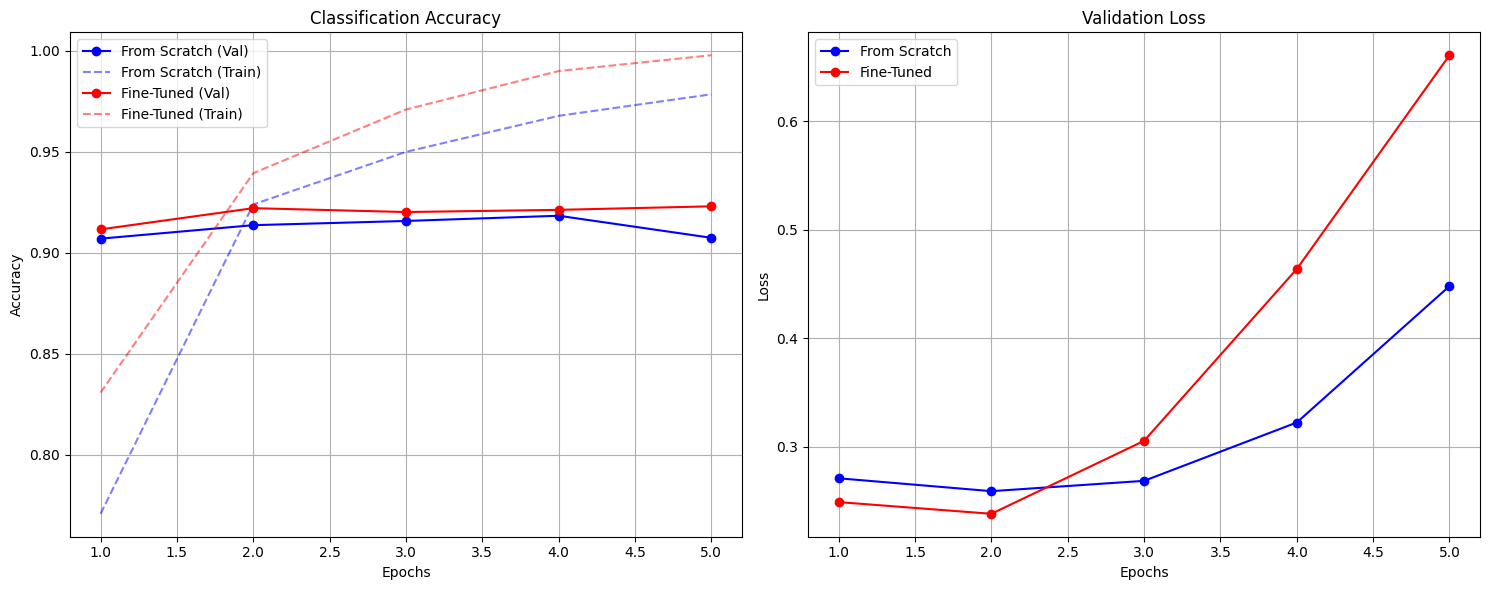


Metric               | From Scratch    | Fine-Tuned     
------------------------------------------------------------
Test Accuracy        | 0.9151          | 0.9218
Test F1 Score        | 0.9144          | 0.9216
Parameters           | 3,434,052       | 68,517,120
Total Train Time     | 697.7s        | 5422.7s
Inference Time       | 2.3s         | 22.8s


In [8]:
def plot_comparisons(scratch_res, ft_res):
    epochs_scratch = range(1, len(scratch_res["history"]["train_loss"]) + 1)
    epochs_ft = range(1, len(ft_res["history"]["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.plot(
        epochs_scratch,
        scratch_res["history"]["val_acc"],
        "b-o",
        label="From Scratch (Val)",
    )
    ax1.plot(
        epochs_scratch,
        scratch_res["history"]["train_acc"],
        "b--",
        alpha=0.5,
        label="From Scratch (Train)",
    )
    ax1.plot(epochs_ft, ft_res["history"]["val_acc"], "r-o", label="Fine-Tuned (Val)")
    ax1.plot(
        epochs_ft,
        ft_res["history"]["train_acc"],
        "r--",
        alpha=0.5,
        label="Fine-Tuned (Train)",
    )
    ax1.set_title("Classification Accuracy")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(
        epochs_scratch, scratch_res["history"]["val_loss"], "b-o", label="From Scratch"
    )
    ax2.plot(epochs_ft, ft_res["history"]["val_loss"], "r-o", label="Fine-Tuned")
    ax2.set_title("Validation Loss")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 60)
    print(f"{'Metric':<20} | {'From Scratch':<15} | {'Fine-Tuned':<15}")
    print("-" * 60)
    print(
        f"{'Test Accuracy':<20} | {scratch_res['test_acc']:.4f}          | {ft_res['test_acc']:.4f}"
    )
    print(
        f"{'Test F1 Score':<20} | {scratch_res['test_f1']:.4f}          | {ft_res['test_f1']:.4f}"
    )
    print(
        f"{'Parameters':<20} | {scratch_res['params']:,}       | {ft_res['params']:,}"
    )
    print(
        f"{'Total Train Time':<20} | {scratch_res['total_train_time']:.1f}s        | {ft_res['total_train_time']:.1f}s"
    )
    print(
        f"{'Inference Time':<20} | {scratch_res['inference_time']:.1f}s         | {ft_res['inference_time']:.1f}s"
    )
    print("=" * 60)


plot_comparisons(scratch_results, ft_results)